# Outlet, Genre, and Lexicon Baseline Analysis

This notebook adds three supporting checks to the main German analysis:

1. **Outlet:** whether MAGPIE scores vary across news outlets.
2. **Genre:** whether opinion/commentary articles receive different scores from straight-news articles.
3. **Lexicon baseline:** whether a simple German sentiment lexicon shows the same left/right pattern as MAGPIE.

All three analyses use the same 1,000-article German sample and sampling procedure as the main analysis, so the results remain directly comparable.


## Setup

In [1]:
!pip install transformers pandas scikit-learn scipy tqdm statsmodels openpyxl -q

In [2]:
from transformers import pipeline

bias_classifier = pipeline(
    "text-classification",
    model="mediabiasgroup/magpie-babe-ft-xlm",
    device=device
)

config.json:   0%|          | 0.00/835 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/451 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

## Load the data and rebuild the main sample

The German corpus is loaded from `poliOscar.complete.de` using the same sampling procedure as the main German analysis: a fixed random seed of 42 is used to select 500 left-labelled and 500 right-labelled articles, followed by a reproducible shuffle. This keeps the supporting analyses directly comparable with the main German analysis.

**Note on loading:** a plain `pd.read_csv` is not used because some articles contain literal tab or line-break characters within the article text, which can interfere with standard tabular parsing. The corpus also contains encoding irregularities from the original web-scraped source. The line-by-line loader below preserves article text while handling these cases.

In [20]:
import pandas as pd

# Load the corpus line by line so that tabs and line breaks
# inside article text are handled without creating malformed rows.

rows = []
skipped = 0
current_row = None

with open("poliOscar.complete.de", encoding="utf-8", errors="replace") as f:
    for line in f:
        line = line.rstrip("\n")

        parts = line.split("\t", maxsplit=5)

        if len(parts) == 6:
            # New article record
            current_row = parts
            rows.append(current_row)

        elif current_row is not None:
            # Continuation of the previous article's text
            current_row[5] += "\n" + line

        else:
            # Malformed line before any valid article record
            skipped += 1

df = pd.DataFrame(
    rows,
    columns=["topic10", "topic15", "stance", "oscarID", "url", "text"]
)

print(df.shape)
print(f"Skipped {skipped} malformed lines")

(140119, 6)
Skipped 0 malformed lines


In [21]:
# Check the loaded German corpus before sampling

print(f"Total usable articles: {len(df):,}")

print("\nStance distribution:")
print(df["stance"].value_counts())

print("\nMissing values:")
print(df[["stance", "oscarID", "url", "text"]].isna().sum())

Total usable articles: 140,119

Stance distribution:
stance
left     88102
right    52017
Name: count, dtype: int64

Missing values:
stance     0
oscarID    0
url        0
text       0
dtype: int64


In [25]:
# Create the balanced 1,000-article sample
# using the same sampling procedure and random seed
# as the final German analysis.

df_usable = df[df["text"].str.strip().ne("")].copy()

left_sample = df_usable[
    df_usable["stance"] == "left"
].sample(n=500, random_state=42)

right_sample = df_usable[
    df_usable["stance"] == "right"
].sample(n=500, random_state=42)

df_sample = (
    pd.concat([left_sample, right_sample])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

assert len(df_sample) == 1000
assert df_sample["stance"].value_counts().to_dict() == {
    "left": 500,
    "right": 500
}
assert df_sample["text"].str.strip().ne("").all()

print(f"Usable articles with non-empty text: {len(df_usable):,}")
print(f"Sample size: {len(df_sample):,}")
print("\nStance distribution:")
print(df_sample["stance"].value_counts())

Usable articles with non-empty text: 140,119
Sample size: 1,000

Stance distribution:
stance
right    500
left     500
Name: count, dtype: int64


In [26]:
# Verify that the sampled articles are unique.

print(f"Unique oscarID: {df_sample['oscarID'].nunique():,}")
print(f"Unique URLs: {df_sample['url'].nunique():,}")
print(f"Duplicate oscarID rows: {df_sample['oscarID'].duplicated().sum():,}")
print(f"Duplicate URL rows: {df_sample['url'].duplicated().sum():,}")

Unique oscarID: 1,000
Unique URLs: 1,000
Duplicate oscarID rows: 0
Duplicate URL rows: 0


## Score every article with MAGPIE

The same sentence-level MAGPIE scores are pooled at article level using average, maximum, and median pooling.

For the average score, this notebook uses the proportion of sentences classified as biased, matching the scoring definition used for this supporting analysis. Maximum and median pooling use the sentence-level biased probabilities.


In [28]:
import re

def split_into_sentences(text):
    paragraphs = text.split("<NS>")
    all_sentences = []
    for para in paragraphs:
        para = para.strip()
        if len(para) == 0:
            continue
        sentences = re.split(r'(?<=[.!?]) +', para)
        all_sentences.extend([s.strip() for s in sentences if len(s.strip()) > 0])
    return all_sentences

In [29]:
import statistics

def score_article(text, classifier, batch_size=32):
    if pd.isna(text) or len(text.strip()) == 0:
        return None, None, None
    sentences = split_into_sentences(text)
    if len(sentences) == 0:
        return None, None, None
    results = classifier(sentences, truncation=True, batch_size=batch_size)
    labels = [r["label"] for r in results]
    biased_probs = [
        r["score"] if r["label"] == "biased" else 1 - r["score"]
        for r in results
    ]
    avg_score = labels.count("biased") / len(labels)
    max_score = max(biased_probs)
    median_score = statistics.median(biased_probs)
    return avg_score, max_score, median_score

In [30]:
from tqdm import tqdm

avg_scores, max_scores, median_scores = [], [], []
for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    avg_s, max_s, median_s = score_article(row["text"], bias_classifier)
    avg_scores.append(avg_s)
    max_scores.append(max_s)
    median_scores.append(median_s)

df_sample["bias_score"] = avg_scores
df_sample["max_bias_score"] = max_scores
df_sample["median_bias_score"] = median_scores

print("Done!")
print(f"Articles with no score (missing text): {df_sample['bias_score'].isna().sum()}")
df_sample = df_sample.dropna(subset=["bias_score"]).reset_index(drop=True)
print("Final usable articles:", df_sample.shape[0])

100%|██████████| 1000/1000 [00:49<00:00, 20.21it/s]

Done!
Articles with no score (missing text): 0
Final usable articles: 1000


---

# Part 1: Does bias score differ by outlet?

In [31]:
from urllib.parse import urlparse

def get_outlet(url):
    domain = urlparse(url).netloc
    return domain.replace("www.", "")

df_sample["outlet"] = df_sample["url"].apply(get_outlet)

print(f"Number of distinct outlets: {df_sample['outlet'].nunique()}")
df_sample["outlet"].value_counts().head(15)

Number of distinct outlets: 12


,count
outlet,
bild.de,214
taz.de,213
sueddeutsche.de,173
faz.net,121
jungefreiheit.de,81
welt.de,79
nd-aktuell.de,43
jungewelt.de,41
dw.com,13


In [32]:
# only comparing outlets with a reasonable number of articles
outlet_counts = df_sample["outlet"].value_counts()
outlets_with_enough_data = outlet_counts[outlet_counts >= 20].index

df_outlets = df_sample[df_sample["outlet"].isin(outlets_with_enough_data)].copy()

print(f"Outlets with at least 20 articles: {len(outlets_with_enough_data)}")
print(f"Articles covered: {len(df_outlets)} of {len(df_sample)}")

df_outlets.groupby("outlet")["bias_score"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)

Outlets with at least 20 articles: 8
Articles covered: 965 of 1000


,mean,median,count
outlet,,,
jungefreiheit.de,0.318559,0.285714,81
taz.de,0.279616,0.250000,213
welt.de,0.263326,0.224490,79
nd-aktuell.de,0.245377,0.232323,43
faz.net,0.241477,0.230769,121
bild.de,0.228456,0.200000,214
sueddeutsche.de,0.220038,0.187500,173
jungewelt.de,0.106859,0.100000,41


In [33]:
from scipy.stats import kruskal

groups = [group["bias_score"].dropna().values for _, group in df_outlets.groupby("outlet")]
stat, p_value_outlet = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"P-value: {p_value_outlet:.4f}")
print(f"Number of outlets compared: {len(groups)}")

if p_value_outlet < 0.05:
    print(">> At least one outlet's bias score differs significantly from the others.")
else:
    print(">> No significant difference in bias score found across outlets.")

Kruskal-Wallis H-statistic: 51.2837
P-value: 0.0000
Number of outlets compared: 8
>> At least one outlet's bias score differs significantly from the others.


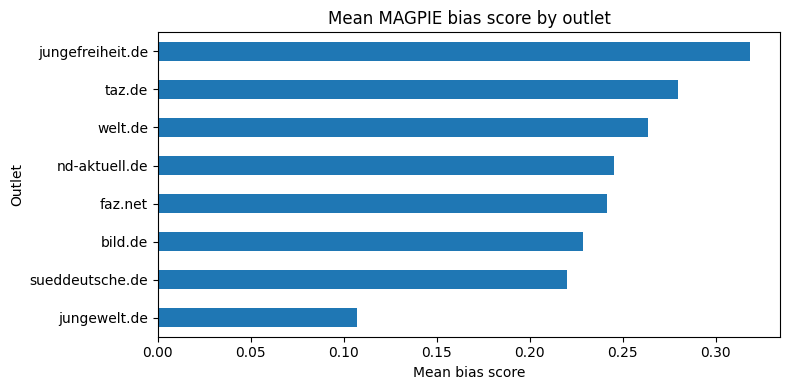

In [34]:
import matplotlib.pyplot as plt

df_outlets.groupby("outlet")["bias_score"].mean().sort_values().plot(
    kind="barh", figsize=(8, max(4, len(outlets_with_enough_data) * 0.35))
)
plt.xlabel("Mean bias score")
plt.ylabel("Outlet")
plt.title("Mean MAGPIE bias score by outlet")
plt.tight_layout()
plt.show()

---

# Part 2: Does bias score differ by genre?

The dataset does not provide a genre label. I therefore use a simple URL-based rule to identify likely opinion or commentary pieces. An article is flagged when its URL contains one of the German terms listed below.

This is deliberately treated as an **exploratory heuristic** rather than a definitive genre classifier: some genuine opinion pieces will not be detected, while some URLs may contain these terms without guaranteeing a particular writing style.


In [36]:
opinion_keywords = ["kommentar", "meinung", "kolumne", "gastbeitrag", "leitartikel"]

def is_opinion(url):
    return any(keyword in url.lower() for keyword in opinion_keywords)

df_sample["is_opinion"] = df_sample["url"].apply(is_opinion)

print(df_sample["is_opinion"].value_counts())
print()
print(df_sample.groupby("is_opinion")["bias_score"].agg(["mean", "median", "count"]))

is_opinion
False    965
True      35
Name: count, dtype: int64

                mean    median  count
is_opinion                           
False       0.236187  0.207317    965
True        0.459568  0.472727     35


In [37]:
from scipy.stats import mannwhitneyu

opinion_scores = df_sample[df_sample["is_opinion"] == True]["bias_score"].dropna()
news_scores = df_sample[df_sample["is_opinion"] == False]["bias_score"].dropna()

stat, p_value_genre = mannwhitneyu(
    opinion_scores,
    news_scores,
    alternative="two-sided"
)

print(f"Opinion/commentary mean: {opinion_scores.mean():.4f} (n={len(opinion_scores)})")
print(f"Straight news mean: {news_scores.mean():.4f} (n={len(news_scores)})")
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"Two-sided p-value: {p_value_genre:.4f}")


Opinion/commentary mean: 0.4596 (n=35)
Straight news mean: 0.2362 (n=965)
Mann-Whitney U statistic: 26459.0
Two-sided p-value: 0.0000


---

# Part 3: Lexicon Baseline Comparison

The final supporting analysis compares MAGPIE with SentiWS, a German sentiment lexicon. The purpose is not to treat SentiWS as a competing bias detector, but to check how much the MAGPIE scores overlap with a simple word-level measure of emotionally charged language.

The comparison uses the same three article-level pooling methods as the MAGPIE analysis.


In [38]:
from datasets import load_dataset

# loading SentiWS from Hugging Face instead of the university server directly,
# since that server is unreliable to reach from Colab
sentiws_data = load_dataset("community-datasets/senti_ws", "sentiment-scoring", split="train")

sentiws = {}
for row in sentiws_data:
    word = row["word"].lower()
    score = row.get("sentiment-score", row.get("sentiment_score"))
    sentiws[word] = score

print(f"Total lexicon entries: {len(sentiws)}")

Total lexicon entries: 3459


A sentence-level lexicon score is the mean absolute SentiWS weight of the words found in that sentence, with a score of 0 when no lexicon words are found. The absolute value measures the strength of the lexical sentiment signal rather than whether it is positive or negative. Therefore, this baseline is used only as a descriptive comparison with MAGPIE and is not interpreted as an independent measure of media bias.

The same three pooling methods are then applied at article level. This makes the comparison descriptive: it asks whether MAGPIE and a simple lexical measure show similar patterns, not whether SentiWS measures media bias.

In [39]:
def lexicon_score_sentence(sentence):
    words = re.findall(r"[a-zA-ZäöüÄÖÜß]+", sentence.lower())
    weights = [abs(sentiws[w]) for w in words if w in sentiws]
    if len(weights) == 0:
        return 0.0
    return sum(weights) / len(weights)

def lexicon_score_article(text):
    if pd.isna(text) or len(text.strip()) == 0:
        return None, None, None
    sentences = split_into_sentences(text)
    if len(sentences) == 0:
        return None, None, None
    scores = [lexicon_score_sentence(s) for s in sentences]
    return sum(scores) / len(scores), max(scores), statistics.median(scores)

In [40]:
lex_avg, lex_max, lex_median = [], [], []
for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    a, m, med = lexicon_score_article(row["text"])
    lex_avg.append(a)
    lex_max.append(m)
    lex_median.append(med)

df_sample["lex_avg"] = lex_avg
df_sample["lex_max"] = lex_max
df_sample["lex_median"] = lex_median

print("Done!")
df_sample[["bias_score", "lex_avg", "max_bias_score", "lex_max"]].head()

100%|██████████| 1000/1000 [00:00<00:00, 2054.15it/s]

Done!


,bias_score,lex_avg,max_bias_score,lex_max
0,0.222222,0.027204,0.964793,0.4940
1,0.111111,0.131389,0.616625,0.6752
2,0.368421,0.037779,0.947677,0.3482
3,0.288462,0.048886,0.967636,0.5391
4,0.055556,0.084211,0.945398,0.6268


## Does the lexicon baseline show the same left/right pattern?

The three pooling methods are tested separately. Because they form a small family of related tests, Bonferroni correction is applied across the three p-values.


In [43]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

lexicon_tests = []

for pooling_col, name in [
    ("lex_avg", "Average"),
    ("lex_max", "Max"),
    ("lex_median", "Median")
]:
    left = df_sample[df_sample["stance"] == "left"][pooling_col].dropna()
    right = df_sample[df_sample["stance"] == "right"][pooling_col].dropna()

    stat, p = mannwhitneyu(
        left,
        right,
        alternative="two-sided"
    )

    lexicon_tests.append({
        "pooling": name,
        "left_mean": left.mean(),
        "right_mean": right.mean(),
        "U_statistic": stat,
        "p_value": p
    })

lexicon_results = pd.DataFrame(lexicon_tests)

reject, p_adjusted, _, _ = multipletests(
    lexicon_results["p_value"],
    method="bonferroni"
)

lexicon_results["p_bonferroni"] = p_adjusted
lexicon_results["significant_after_bonferroni"] = reject

print(lexicon_results)


   pooling  left_mean  right_mean  U_statistic   p_value  p_bonferroni  \
0  Average   0.063855    0.069530     118805.0  0.174947      0.524842   
1      Max   0.513285    0.467208     141099.5  0.000422      0.001266   
2   Median   0.005615    0.008041     117982.5  0.053962      0.161887   

   significant_after_bonferroni  
0                         False  
1                          True  
2                         False  


## Does MAGPIE agree with the lexicon?

Spearman correlation is used to describe the degree of overlap between the MAGPIE scores and the SentiWS-based scores. A correlation close to zero would indicate little shared ordering of articles, whereas a positive correlation would indicate some common signal.

This is a descriptive comparison. Correlation alone cannot show that MAGPIE captures a particular type of language or that it captures something the lexicon cannot.


In [42]:
from scipy.stats import spearmanr

for magpie_col, lex_col, name in [("bias_score", "lex_avg", "Average"),
                                    ("max_bias_score", "lex_max", "Max"),
                                    ("median_bias_score", "lex_median", "Median")]:
    valid = df_sample[[magpie_col, lex_col]].dropna()
    corr, p = spearmanr(valid[magpie_col], valid[lex_col])
    print(f"{name} pooling: Spearman correlation between MAGPIE and lexicon = {corr:.4f} (p = {p:.4f})")

Average pooling: Spearman correlation between MAGPIE and lexicon = 0.2360 (p = 0.0000)
Max pooling: Spearman correlation between MAGPIE and lexicon = 0.4014 (p = 0.0000)
Median pooling: Spearman correlation between MAGPIE and lexicon = 0.1041 (p = 0.0010)


## Result

### Outlet

Eight outlets had at least 20 articles in the sample, covering 965 of the 1,000 articles. MAGPIE scores differed significantly across these outlets according to the Kruskal-Wallis test (H = 51.28, p < 0.001).

This result should be interpreted as an **outlet-level difference**, not as evidence that MAGPIE detects a particular political direction. The political stance label in this dataset is assigned at outlet level, so stance and outlet are perfectly nested. The outlet analysis therefore provides evidence that publisher-level differences are present, but it cannot separate outlet identity from the stance label.

### Genre

The URL-based heuristic flagged 35 of the 1,000 articles as opinion/commentary. Opinion-labelled articles had a higher mean MAGPIE score than the remaining straight-news group (0.4596 vs. 0.2362).

The difference was statistically significant in a two-sided Mann-Whitney U test (U = 26,459, p < 0.001). However, because only 35 articles were identified as opinion/commentary and the classification is based only on URL keywords, this result is treated as **exploratory evidence** rather than a definitive genre effect.

### Lexicon baseline

The SentiWS comparison provides a simple lexical baseline for the MAGPIE scores. The three pooling methods are tested separately and Bonferroni correction is applied across those tests.

The average and median pooling comparisons did not show significant left-right differences after Bonferroni correction (p = 0.5248 and p = 0.1619, respectively). The maximum-pooling comparison was significant after correction (p = 0.0013).

Spearman correlations between MAGPIE and SentiWS scores indicate positive association across all three pooling methods: average pooling (ρ = 0.2360, p < 0.001), maximum pooling (ρ = 0.4014, p < 0.001), and median pooling (ρ = 0.1041, p = 0.0010). These correlations indicate that the two measures share some signal but are not identical.

The lexicon results are therefore interpreted alongside the MAGPIE results rather than as a direct test of political bias. The differing results across pooling strategies also indicate that conclusions can depend on how sentence-level scores are aggregated.

### Overall interpretation

Taken together, these supporting analyses show that MAGPIE scores vary with **outlet, genre-related indicators, and lexical characteristics**. They do not by themselves establish that MAGPIE measures political stance. Because outlet and political stance are nested in the German dataset, and because the genre classifier is heuristic, these results are treated as supporting and exploratory evidence rather than independent causal explanations.